**Cladocopium from Acropora cf tenuis samples in the central Philippines isolation by distance**

_Inputs_:
Metadata with lat/lons of sampling locations\
SNP data from each cryptic taxon in genind format\
_Outputs_:
Fst and linearized Fst between each pair of sites\
Great circle distances between each pair of sites\
Linear regressions and Mantel tests\
Figures\
Created by Jaelyn Bos 2025

In [1]:
#Make sure R can find packages installed through Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [2]:
#Load required packages
library(adegenet)
library(hierfstat)
library(tidyverse)
library(vegan)
library(vcfR)
library(sp)
library(sf)
library(viridis)
library(cowplot)

Loading required package: ade4


   /// adegenet 2.1.11 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()




Attaching package: ‘hierfstat’


The following objects are masked from ‘package:adegenet’:

    Hs, read.fstat


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-8


   *****       ***   vcfR   ***       *****
   This is vcfR 1

In [3]:
#Calculate great circle distances from lat/lons
wide_dists <- function(sites){
    x<-st_as_sf(sites,coords=c('LONGITUDE','LATITUDE'))
    x<-st_set_crs(x,4326)
    d <- st_distance(x)
    colnames(d)<-sites$Name
    rownames(d)<-sites$Name
    d<-as.data.frame(d)
    return(d)
}

In [4]:
#Calculate great circle distances from lat/lons
wide_dists2 <- function(sites){
    x<-st_as_sf(sites,coords=c('lon_flat','lat_flat'))
    x<-st_set_crs(x,4326)
    d <- st_distance(x)
    colnames(d)<-sites$release_flat
    rownames(d)<-sites$release_flat
    d<-as.data.frame(d)
    return(d)
}

In [5]:
#Inputs: wide form FSTs and dataframe of individuals corresponding to each population
#Output: long form FSTs. Columns: siteA	siteB	fst	siteA_counts	siteB_counts	mean_counts
fst_transform<-function(fsts,indpops){
    fst_long<-pivot_longer(fsts,cols=colnames(fsts)[2:length(colnames(fsts))],names_to='siteB',values_to='fst')
    colnames(fst_long)<-c('siteA','siteB','fst')
    fst_long<-fst_long[!is.nan(fst_long$fst),]
    dum<-as.data.frame(table(indpops$Population))
    colnames(dum)<-c('siteA','siteA_counts')
    fst_long<-left_join(fst_long,dum,by='siteA')
    colnames(dum)<-c('siteB','siteB_counts')
    fst_long<-left_join(fst_long,dum,by='siteB')
    fst_long$mean_counts<-rowMeans(as.data.frame(cbind(fst_long$siteA_counts,fst_long$siteB_counts)))
    return(fst_long)
}

In [6]:
#Inputs: wide form FSTs and dataframe of individuals corresponding to each population
#Output: wide form linearized FSTs for Mantel tests and figures
linear_fsts<-function(wide_fsts){
  wide_fsts<-as.data.frame(wide_fsts)
  rownames(wide_fsts)<-wide_fsts[,1]
  wide_fsts<-wide_fsts[,-1]
  fst_lin <- wide_fsts/(1-wide_fsts)
  return(fst_lin)
}

In [7]:
#Inputs: wide form FSTs and dataframe of individuals corresponding to each population
#Output: wide form linearized FSTs for Mantel tests and figures
linear_fsts2<-function(wide_fsts){
  wide_fsts<-as.data.frame(wide_fsts)
  fst_lin <- wide_fsts/(1-wide_fsts)
  return(fst_lin)
}

In [8]:
#Inputs: wide form linearized FSTs and wide form distances for each cryptic taxon
#Outputs: long form dataframe with columns SiteA	SiteB	Lin_FST	Distance_m
fst_dist_join<-function(fsts_linear, distances){
    fsts_linear$SiteA<-rownames(fsts_linear)
    distances$SiteA<-rownames(distances)
    fst_lin_lon<-pivot_longer(data=fsts_linear,cols=colnames(fsts_linear)[!(colnames(fsts_linear) %in% 'SiteA')],names_to='SiteB',values_to='Lin_FST')
    dists_lon<-pivot_longer(data=distances,cols=colnames(distances)[!(colnames(distances) %in% 'SiteA')],names_to='SiteB',values_to='Distance_m')
    mer<-inner_join(fst_lin_lon,dists_lon)
    mer<-mer[mer$SiteA!=mer$SiteB,]
    mer$Distance_m<-as.numeric(mer$Distance_m)
    mer_uniquerows <- mer %>% distinct(Distance_m, .keep_all = TRUE)
    return(mer_uniquerows)
    }

In [21]:
#Count individuals per population
make_counts<-function(inds_per_pop){
    dummy<-as.data.frame(matrix(nrow=length(unique(inds_per_pop$Population))))
    dummy[,1]<-unique(inds_per_pop$Population)
    dummy[,2]<-table(inds_per_pop$Population)
    colnames(dummy)<-c('pop','count')
    return(dummy)
    }

In [9]:
#Function to create long form dataset containing pairwise FSTs and corresponding release sites.
#Note that due to differing spatial grains multiple pairwise FST values will correspond to each release site pair!
fst_transform2<-function(fsts,sitesA,sitesB){
    colnames(fsts)[1]<-'siteA'
    fst_long<-pivot_longer(fsts,cols=colnames(fsts)[2:length(colnames(fsts))],names_to='siteB',values_to='fst')
    colnames(fst_long)<-c('siteA','siteB','fst')
    fst_long<-fst_long[!is.nan(fst_long$fst),]
    fst_long<-left_join(fst_long,sitesA,by='siteA')
    fst_long<-left_join(fst_long,sitesB,by='siteB')
    fst_long$release<-paste(fst_long$release_siteA,fst_long$release_siteB)
    return(fst_long)
}

In [10]:
#Stick together data for figure making
join_for_fig<-function(merged_data,long_fsts){
    merged_data$SiteAB<-paste(merged_data$SiteA,merged_data$SiteB)
    long_fsts$SiteAB<-paste(long_fsts$siteA,long_fsts$siteB)
    new<-left_join(merged_data,long_fsts,by='SiteAB')
    new$Distance_km<-new$Distance_m/1000
    new<-new[,c('SiteA','SiteB','Lin_FST','Distance_m','mean_counts','Distance_km')]
    }

In [11]:
#Input: FSTs, vector of number of individuals per population, minimum number of individuals per popualtion
#Output: Matrix of FSTs including only populations above the minimum size
fst_trim_by_N<-function(fsts,inds_per_pop,min_n){
    fsts<-as.data.frame(fsts)
    fst_trim<-fsts[fsts$...1 %in% as.data.frame(table(inds_per_pop$Population)[table(inds_per_pop$Population)>(min_n-1)])$Var1,]
    fst_trim<-fst_trim[,colnames(fst_trim)%in% as.data.frame(table(inds_per_pop$Population)[table(inds_per_pop$Population)>(min_n-1)])$Var1]
    rownames(fst_trim)<-colnames(fst_trim)
    return(fst_trim)
    }

In [12]:
#Read in sites with lat/lons
sites <- read.csv("all_Atenuis_sites_FIXED.csv")

In [13]:
#Read in VCF of SNPs from reads mapped to Cladocopium genome
vcf<-read.vcfR("/hb/scratch/jbos/cladocopium/pruned_snps.vcf")

Scanning file to determine attributes.
File attributes:
  meta lines: 699
  header_line: 700
  variant count: 873
  column count: 319
Meta line 699 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 873
  Character matrix gt cols: 319
  skip: 0
  nrows: 873
  row_num: 0
Processed variant: 873
All variants processed


In [14]:
#Convert VCF to genind and create population variable from sampling locations
genind0 <- vcfR2genind(vcf)
genind0@pop <-as.factor(unlist(lapply(strsplit(rownames(genind0$tab),"_"), head, 1)))

In [15]:
#Get metadata for only sites with samples
sites0<-sites[sites$Name %in% unique(genind0@pop),]

In [16]:
#Convert genind to hierfstat to prepare for FST calculation
hstat0<-genind2hierfstat(genind0,pop=genind0@pop)

In [17]:
#Convert distances to wide form
dists0<-wide_dists(sites0)

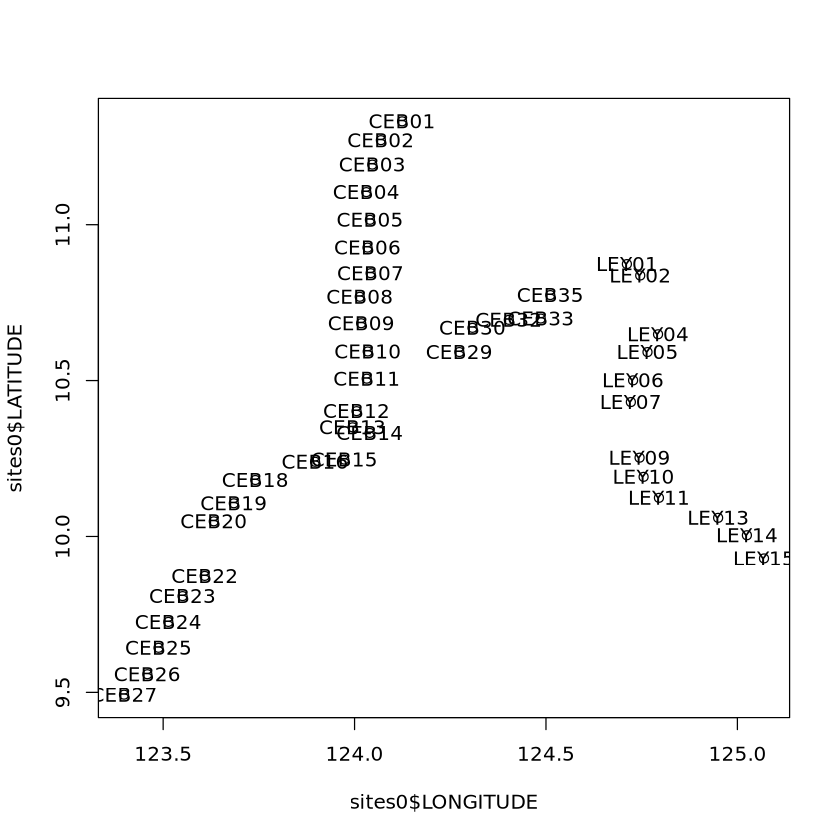

In [16]:
#Plot site names on lat/lons as sanity check
plot(sites0$LONGITUDE, sites0$LATITUDE,text(sites0$LONGITUDE, sites0$LATITUDE,sites0$Name))

In [17]:
#Make sf object out of points(this will be useful later)
sites_sf<-st_as_sf(sites,coords=c('LONGITUDE','LATITUDE'))
sites_sf<-st_set_crs(sites_sf,4326)
sitepoints<-st_combine(sites_sf)
sites_proj<-st_transform(sitepoints,crs=9834)

In [22]:
#Calculate FSTs between sampling sites (note that this is time consuming)
#fsts<-pairwise.WCfst(hstat0)
#write.csv(fsts,'cladocopium_fsts_all_update.csv',row.names=TRUE)

In [18]:
#Alternatively, read in FSTs
fsts<-as.data.frame(read_csv('cladocopium_fsts_all_update.csv',show_col_types = FALSE))

New names:
• `` -> `...1`


In [19]:
#Read in between population FSTs for Acropora
acropora_fsts<-read_csv('fst_all_pruned.csv')

New names:
• `` -> `...1`
Rows: 42 Columns: 43
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (42): CEB01, CEB02, CEB03, CEB04, CEB05, CEB06, CEB07, CEB08, CEB09, CEB...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [20]:
#Count individuals per population. Obviously this is individual corals per site, not individiual symbionts
inds_per_pop0<-as.data.frame(cbind(rownames(genind0@tab),as.character(genind0@pop)))
colnames(inds_per_pop0)<-c("Individual","Population")

In [41]:
c1<-make_counts(inds_per_pop0)
acropora_counts<-read.csv('site_counts.csv')
counts<-full_join(c1,acropora_counts)
counts<-counts[,-3]
write.csv(counts,'site_counts_clad.csv')

Joining with `by = join_by(pop)`


In [23]:
#Convert FSTs to long form
fsts_long<-fst_transform(fsts,inds_per_pop0)

In [24]:
#Calculate linearized FSTs from wide form FSTs
fst_lin<-as.data.frame(linear_fsts(fsts))

In [25]:
#Select sites from Cebu only and Leyte only
Ceb_real <- sites[sites$LONGITUDE<124.25,3]
Leyte<-sites[substr(sites$Name,start=1,stop=3)=='LEY',3]

In [26]:
#Take log of distance for 2D Mantel test
log_dist<-log(dists0)

In [28]:
#Create "inds_per_pop" variable to throw out populations with single individuals that are throwing errors
inds_per_pop<-as.data.frame(cbind(rownames(genind0@tab),as.character(genind0@pop)))
colnames(inds_per_pop)<-c("Individual","Population")

In [29]:
#Throw out populations with single individuals
fst_trim<-fst_trim_by_N(fsts,inds_per_pop,2)

In [30]:
#Do the same thing with linearized FSTs
fst_lin_trim<-as.data.frame(linear_fsts2(fst_trim))

In [31]:
#Make distance df with the same dimentions as the fst df
dists_trim<-dists0[rownames(dists0) %in% colnames(fst_trim),colnames(dists0) %in% colnames(fst_trim)]
log_dist_trim<-log(dists_trim)

In [32]:
#Make dataframes of linearized FSTs for Leyte only and Cebu only
fst_Cebu<-fst_lin[rownames(fst_lin) %in% Ceb_real, colnames(fst_lin) %in% Ceb_real]
fst_Leyte<-fst_lin[rownames(fst_lin) %in% Leyte, colnames(fst_lin) %in% Leyte]

In [33]:
#Make dataframes of linearized FSTs for Leyte only and Cebu only
fst_Cebu_trim<-fst_lin_trim[rownames(fst_lin_trim) %in% Ceb_real, colnames(fst_lin_trim) %in% Ceb_real]
fst_Leyte_trim<-fst_lin_trim[rownames(fst_lin_trim) %in% Leyte, colnames(fst_lin_trim) %in% Leyte]

In [34]:
#Make dataframes of between site distances for Leyte only and Cebu only
dists_Cebu<-dists0[rownames(dists0) %in% Ceb_real, colnames(dists0) %in% Ceb_real]
dists_Leyte<-dists0[rownames(dists0) %in% Leyte, colnames(dists0) %in% Leyte]

In [35]:
#Make dataframes of between site distances for Leyte only and Cebu only
dists_Cebu_trim<-dists_trim[rownames(dists_trim) %in% Ceb_real, colnames(dists_trim) %in% Ceb_real]
dists_Leyte_trim<-dists_trim[rownames(dists_trim) %in% Leyte, colnames(dists_trim) %in% Leyte]

In [142]:
#Two dimensional Mantel test. Try again with N>1 sites. 
set.seed(42)
mantel(fst_lin_trim,log_dist_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin_trim, ydis = log_dist_trim) 

Mantel statistic r: 0.1499 
      Significance: 0.002 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0773 0.0945 0.1084 0.1239 
Permutation: free
Number of permutations: 999


In [144]:
#One dimensional Mantel test, N>1 sites
set.seed(42)
mantel(fst_Cebu_trim,dists_Cebu_trim)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_Cebu_trim, ydis = dists_Cebu_trim) 

Mantel statistic r: 0.3016 
      Significance: 0.001 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.105 0.132 0.158 0.183 
Permutation: free
Number of permutations: 999


In [39]:
#Reshape data for linear models and plotting
merge_trim<-fst_dist_join(fst_lin_trim,dists_trim)
merge_trim$Dist_log<-log(merge_trim$Distance_m)
merge_trim$Dist_log_km<-log(merge_trim$Distance_m/1000)
merge_Ceb_trim<-fst_dist_join(fst_Cebu_trim,dists_Cebu_trim)
merge_Ceb_trim$Dist_km<-(merge_Ceb_trim$Distance_m/1000)

Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`


In [146]:
#Get standard error of IBD slope and mean slope, trimmed data. Resample 1000 times.
set.seed(42)
se_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge_trim))$coefficients[2,2]
m_trim<-summary(lm(Lin_FST ~ Dist_log,dat=merge_trim))$coefficients[2,1]
ms_trim<-rnorm(1000, mean = m_trim, sd = se_trim)

se_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge_trim))$coefficients[2,2]
m_km_trim<-summary(lm(Lin_FST ~ Dist_log_km,dat=merge_trim))$coefficients[2,1]
ms_km_trim<-rnorm(1000, mean = m_km_trim, sd = se_km_trim)

In [145]:
#Get standard error of IBD slope and mean slope for Cebu. Resample 1000 times.
set.seed(42)

se_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge_Ceb_trim))$coefficients[2,2]
m_Ceb_trim<-summary(lm(Lin_FST ~ Distance_m,dat=merge_Ceb_trim))$coefficients[2,1]
ms_Ceb_trim<-rnorm(1000, mean = m_Ceb_trim, sd = se_Ceb_trim)

se_Ceb_km_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge_Ceb_trim))$coefficients[2,2]
m_Ceb_km_trim<-summary(lm(Lin_FST ~ Dist_km,dat=merge_Ceb_trim))$coefficients[2,1]
ms_Ceb_km_trim<-rnorm(1000, mean = m_Ceb_km_trim, sd = se_Ceb_km_trim)

In [43]:
m_trim
se_trim

m_Ceb_trim
se_Ceb_trim

[1] 0.005548988

[1] 0.001420438

[1] 9.212117e-08

[1] 1.759149e-08

In [147]:
#Check quantiles of resampled slopes, as well as % positive
m_trim
quantile(ms_trim,probs=c(0.025,0.975))
table(ms_trim>0)

[1] 0.005548988

2.5%       97.5% 
0.002696896 0.008216146


TRUE 
1000 

In [148]:
#Check quantiles of resampled slopes, as well as % positive, Cebu
m_Ceb_trim
quantile(ms_Ceb_trim,probs=c(0.025,0.975))
table(ms_Ceb_trim>0)

[1] 9.212117e-08

2.5%        97.5% 
5.679928e-08 1.251527e-07


TRUE 
1000 

In [46]:
#2D isolation by distance linear model
summary(lm(Lin_FST ~ log(Distance_m), data=merge_trim))


Call:
lm(formula = Lin_FST ~ log(Distance_m), data = merge_trim)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.092106 -0.014438 -0.003798  0.009217  0.166989 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -0.042763   0.016021  -2.669 0.007790 ** 
log(Distance_m)  0.005549   0.001420   3.907 0.000103 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02699 on 664 degrees of freedom
Multiple R-squared:  0.02247,	Adjusted R-squared:  0.02099 
F-statistic: 15.26 on 1 and 664 DF,  p-value: 0.0001032


In [47]:
#1D isolation by distance linear model, Cebu only
summary(lm(Lin_FST ~ Distance_m, data=merge_Ceb_trim))


Call:
lm(formula = Lin_FST ~ Distance_m, data = merge_Ceb_trim)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.062850 -0.010342 -0.000510  0.009673  0.052605 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.090e-02  1.696e-03   6.430 5.66e-10 ***
Distance_m  9.212e-08  1.759e-08   5.237 3.26e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01534 on 274 degrees of freedom
Multiple R-squared:  0.09098,	Adjusted R-squared:  0.08766 
F-statistic: 27.42 on 1 and 274 DF,  p-value: 3.261e-07


`geom_smooth()` using formula = 'y ~ x'
Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'summary': object 'merge_Ceb2' not found


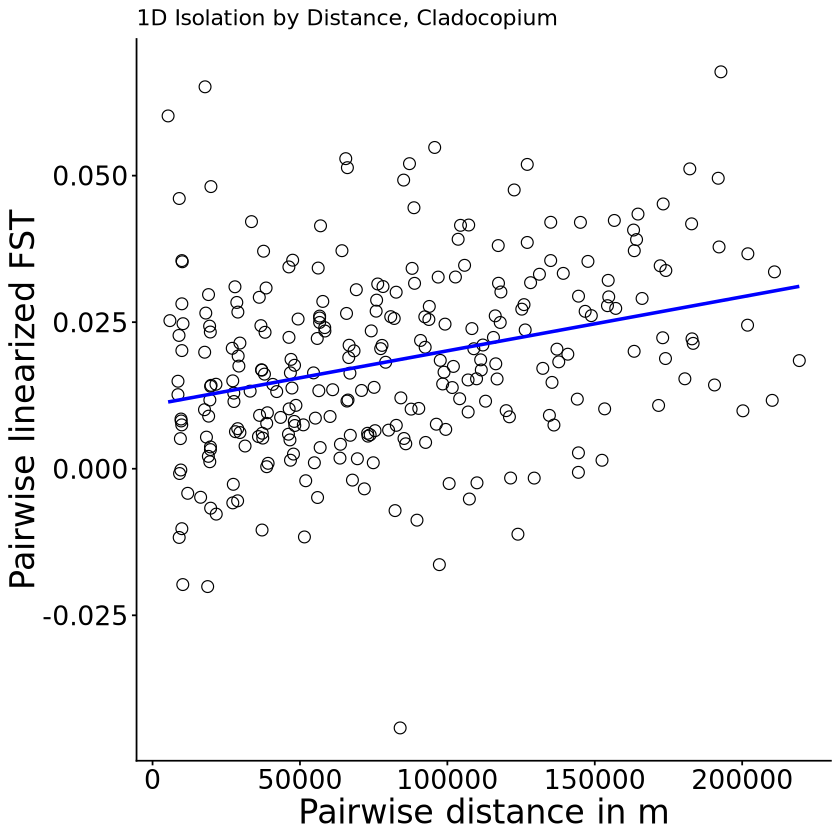

In [49]:
#Plot data for Cebu only
ggplot(merge_Ceb_trim, aes(x=Distance_m, y=Lin_FST)) + geom_point(shape=1,size=3)+
theme_classic()+
theme(axis.text.x = element_text(size = 16),axis.text.y = element_text(size = 16),axis.title.x = element_text(size = 20),axis.title.y = element_text(size = 20))+
ggtitle('1D Isolation by Distance, Cladocopium')+
geom_smooth(method=lm, color="blue",se=FALSE)+
labs(x="Pairwise distance in m", y = "Pairwise linearized FST")
ggsave('Cladocopium_Cebu2.png',dpi = 1200)

summary(lm(Lin_FST ~ LogDist, data=merge_Ceb2))

In [50]:
#Combine data for figure
figdat_Cladocopium<-join_for_fig(merge_trim,fsts_long)
figdat_Cladocopium_1D<-join_for_fig(merge_Ceb_trim,fsts_long)
figdat_Cladocopium_1D$Distance_km<-figdat_Cladocopium_1D$Distance_m/1000

In [80]:
#Calculate confidence interval around slope 1D
slope_min_1D<-quantile(ms_Ceb_km_trim,probs=c(0.025))
slope_max_1D<-quantile(ms_Ceb_km_trim,probs=c(0.975))
intercept_1D<-lm(Lin_FST ~ Distance_km, data = figdat_Cladocopium)$coefficients[1]
value_min_1D<-intercept_1D+slope_min_1D*(figdat_Cladocopium_1D$Distance_km)
value_max_1D<-intercept_1D+slope_max_1D*(figdat_Cladocopium_1D$Distance_km)

In [81]:
#Calculate confidence interval around slope 2D
slope_min_2D<-quantile(ms_km_trim,probs=c(0.025))
slope_max_2D<-quantile(ms_km_trim,probs=c(0.975))
intercept_2D<-lm(Lin_FST ~ log(Distance_km), data = figdat_Cladocopium)$coefficients[1]
value_min_2D<-intercept_2D+slope_min_2D*log(figdat_Cladocopium$Distance_km)
value_max_2D<-intercept_2D+slope_max_2D*log(figdat_Cladocopium$Distance_km)

In [82]:
#Function to make plot, 1D side. (Cebu only, linear relationship with distance).
fst_plot_linear <- function(data, color, title, fsts_lin, dists, xlabel = NULL, ylabel = NULL){
  pl <- ggplot(data, aes(x = as.numeric(Distance_km), y = Lin_FST)) +
    geom_point(aes(size = mean_counts), col = color, alpha = 0.5) +
    geom_ribbon(aes(ymin = value_min_1D, ymax = value_max_1D), fill = color, alpha = 0.3) +
    xlab(xlabel) +
    ylab(ylabel) +
    scale_size_continuous(name = "Mean \nsamples\nper site \npair", range = c(0.5, 0.5*max(data$mean_counts))) +
    theme_minimal() +
    theme(axis.text.x = element_text(size = 16),
          axis.title.x = element_text(size = 19),
          axis.text.y = element_text(size = 16),
          axis.title.y = element_text(size = 19),
          plot.margin = unit(c(0, 0, 0, 0), "cm"),
          panel.grid.minor = element_blank())  
  return(pl) 
}


In [83]:
#Function to make plot, 2D side. (All sites, log-linear relationship with distance).
fst_plot<-function(data,color,title,fsts_lin,log_dists,xlabel=NULL,ylabel=NULL){
  pl<-ggplot(data, aes(x = as.numeric(Distance_km), y = Lin_FST)) +
  geom_point(aes(size=mean_counts),col=color,alpha =0.5) +
  geom_ribbon(aes(ymin = value_min_2D, ymax = value_max_2D), fill =color, alpha = 0.3) +
  xlab(xlabel) +
  ylab(ylabel) +
  #ylim(-0.01,0.015) +
  scale_x_continuous(trans='log10') +
  scale_size_continuous(name ="Mean \nsamples\nper site \npair", range = c(0.5, 0.5*max(data$mean_counts))) +
    theme_minimal() +
    theme(axis.text.x = element_text(size = 16),
          axis.title.x = element_text(size = 19),
          axis.text.y = element_text(size = 16),
          axis.title.y = element_text(size = 19),
          plot.margin = unit(c(0, 0, 0, 0),"cm"),
          panel.grid.minor = element_blank())  
  return(pl) 
}

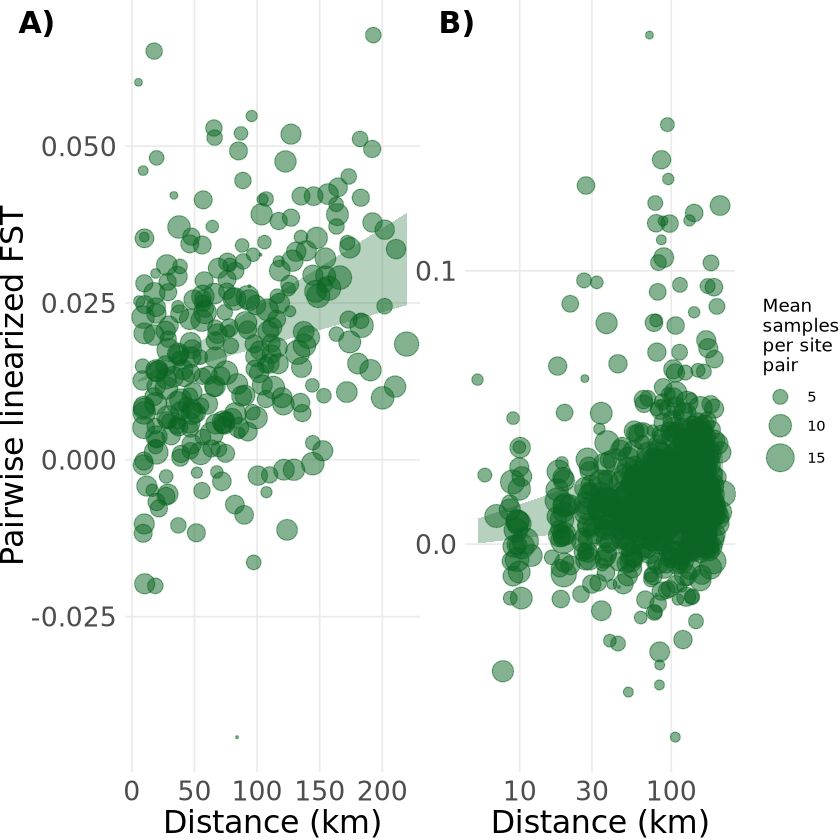

In [84]:
# Create left panel (linear x-axis, no legend)
left_plot <- fst_plot_linear(figdat_Cladocopium_1D, "#0B6623", 'Cladocopium',
                              fsts_lin = fst_lin, dists = Dist_km,
                              ylabel = "Pairwise linearized FST",
                              xlabel = 'Distance (km)') +
  theme(legend.position = "none")

# Create right panel (log x-axis)
right_plot <- fst_plot(figdat_Cladocopium, "#0B6623", 'Cladocopium',
                       fsts_lin = fst_lin, log_dists = log_dist,
                       xlabel = 'Distance (km)')

# Combine with cowplot
combined_plot <- plot_grid(left_plot, right_plot, 
                          labels = c('A)', 'B)'), 
                          label_size = 18,
                          ncol = 2)

# Save with wider dimensions
#ggsave("combined_cladocopium_plot.jpg", combined_plot, width = 16, height = 5, dpi = 800)
print(combined_plot)

In [85]:
#Get N (number of sites) for 1D and 2D analysis
length(unique(figdat_Cladocopium_1D$SiteA))
length(unique(figdat_Cladocopium$SiteA))

[1] 23

[1] 36

In [86]:
#Read in FSTs of  Acropora populations (all cryptic taxa together)
acropora_fstall<-read_csv('fst_all_pruned.csv',show_col_types = FALSE)
fst_acropora_lin<-as.data.frame(linear_fsts(acropora_fstall))
fst_acropora_lin<-fst_acropora_lin[rownames(fst_acropora_lin) %in% rownames(fst_lin_trim),colnames(fst_acropora_lin) %in% colnames(fst_lin_trim)]

New names:
• `` -> `...1`


In [141]:
#Mantel test: Cladocopium FSTs from Acropora FSTs
set.seed(42)
mantel(fst_lin_trim,fst_acropora_lin)


Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel(xdis = fst_lin_trim, ydis = fst_acropora_lin) 

Mantel statistic r: 0.0432 
      Significance: 0.287 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.117 0.170 0.254 0.325 
Permutation: free
Number of permutations: 999


In [136]:
#Partial Mantel test: Cladocopium FSTs from geographic distance conditioned on Acropora FSTs
set.seed(42)
mantel.partial(fst_lin_trim,log_dist_trim,fst_acropora_lin)


Partial Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel.partial(xdis = fst_lin_trim, ydis = log_dist_trim, zdis = fst_acropora_lin) 

Mantel statistic r: 0.1455 
      Significance: 0.004 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0788 0.0951 0.1077 0.1193 
Permutation: free
Number of permutations: 999


In [137]:
#Partial Mantel test: Cladocopium FSTs from Acropora FSTsconditioned on geographic distance 
set.seed(42)
mantel.partial(fst_lin_trim,fst_acropora_lin,log_dist_trim)


Partial Mantel statistic based on Pearson's product-moment correlation 

Call:
mantel.partial(xdis = fst_lin_trim, ydis = fst_acropora_lin,      zdis = log_dist_trim) 

Mantel statistic r: 0.02354 
      Significance: 0.347 

Upper quantiles of permutations (null model):
  90%   95% 97.5%   99% 
0.117 0.173 0.254 0.329 
Permutation: free
Number of permutations: 999


In [90]:
#Read in list of individuals belonging to each Acropora taxon
taxa1<-read_csv('taxa1_inds_copy.csv',show_col_types = FALSE)$x
taxa1<-taxa1[taxa1 %in% rownames(genind0@tab)]
taxa2<-read_csv('taxa2_inds_copy.csv',show_col_types = FALSE)$x
taxa2<-taxa2[taxa2 %in% rownames(genind0@tab)]
taxa3<-read_csv('taxa3_inds_copy.csv',show_col_types = FALSE)$x
taxa3<-taxa3[taxa3 %in% rownames(genind0@tab)]
taxa4<-read_csv('taxa4_inds_copy.csv',show_col_types = FALSE)$x
taxa4<-taxa4[taxa4 %in% rownames(genind0@tab)]

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [91]:
#Separate Cladocopium belonging to samples from each cryptic taxon
clad1<-genind0[taxa1,]
clad2<-genind0[taxa2,]
clad3<-genind0[taxa3,]
clad4<-genind0[taxa4,]

In [92]:
#Get metadata for only sites with samples by cryptic taxon
sites1<-sites[sites$Name %in% unique(clad1@pop),]
dists1<-wide_dists(sites1)
sites2<-sites[sites$Name %in% unique(clad2@pop),]
dists2<-wide_dists(sites2)
sites3<-sites[sites$Name %in% unique(clad3@pop),]
dists3<-wide_dists(sites3)
sites4<-sites[sites$Name %in% unique(clad4@pop),]
dists4<-wide_dists(sites4)

In [93]:
#Convert to hierfstat
hstat1<-genind2hierfstat(clad1,pop=clad1@pop)
hstat2<-genind2hierfstat(clad2,pop=clad2@pop)
hstat3<-genind2hierfstat(clad3,pop=clad3@pop)
hstat4<-genind2hierfstat(clad4,pop=clad4@pop)

In [114]:
#Calculate FSTs between sampling sites (note that this is time consuming)
#fsts<-pairwise.WCfst(hstat1)
#write.csv(fsts,'cladocopium_fsts_taxa1_pruned.csv',row.names=TRUE)

In [113]:
#Calculate FSTs between sampling sites (note that this is time consuming)
#fsts<-pairwise.WCfst(hstat2)
#write.csv(fsts,'cladocopium_fsts_taxa2_pruned.csv',row.names=TRUE)

In [112]:
#Calculate FSTs between sampling sites (note that this is time consuming)
#fsts<-pairwise.WCfst(hstat3)
#write.csv(fsts,'cladocopium_fsts_taxa3_pruned.csv',row.names=TRUE)

In [111]:
#Calculate FSTs between sampling sites (note that this is time consuming)
#fsts<-pairwise.WCfst(hstat4)
#write.csv(fsts,'cladocopium_fsts_taxa4_pruned.csv',row.names=TRUE)

In [94]:
#Alternatively, read in FSTs for Cladocopium in each Acropora cryptic taxon
fsts1<-linear_fsts(read.csv('cladocopium_fsts_taxa1_pruned.csv'))
fsts2<-linear_fsts(read.csv('cladocopium_fsts_taxa2_pruned.csv'))
fsts3<-linear_fsts(read.csv('cladocopium_fsts_taxa3_pruned.csv'))
fsts4<-linear_fsts(read.csv('cladocopium_fsts_taxa4_pruned.csv'))

In [95]:
#Merge Acropora FSTs and geographic distances
merge1<-fst_dist_join(fsts1,dists1)
merge1$Dist_log<-log(merge1$Distance_m)

merge2<-fst_dist_join(fsts2,dists2)
merge2$Dist_log<-log(merge2$Distance_m)

merge3<-fst_dist_join(fsts3,dists3)
merge3$Dist_log<-log(merge3$Distance_m)

merge4<-fst_dist_join(fsts4,dists4)
merge4$Dist_log<-log(merge4$Distance_m)

Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`
Joining with `by = join_by(SiteA, SiteB)`


In [96]:
#Trim so N>1 at all sites
merge1_trim<-merge1[(merge1$SiteA %in% colnames(fst_trim) & merge1$SiteB %in% colnames(fst_trim)),]
merge2_trim<-merge2[(merge2$SiteA %in% colnames(fst_trim) & merge2$SiteB %in% colnames(fst_trim)),]
merge3_trim<-merge3[(merge3$SiteA %in% colnames(fst_trim) & merge3$SiteB %in% colnames(fst_trim)),]
merge4_trim<-merge4[(merge4$SiteA %in% colnames(fst_trim) & merge4$SiteB %in% colnames(fst_trim)),]

In [97]:
#Get rid of additional NAs that make analysis impossible
merge1_trim<-merge1_trim[!is.na(merge1_trim$Lin_FST),]
merge2_trim<-merge2_trim[!is.na(merge2_trim$Lin_FST),]
merge3_trim<-merge3_trim[!is.na(merge3_trim$Lin_FST),]
merge4_trim<-merge4_trim[!is.na(merge4_trim$Lin_FST),]

In [149]:
#Slope, etc. for taxa 1
set.seed(42)
se1<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_trim))$coefficients[2,2]
m1<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_trim))$coefficients[2,1]
ms1<-rnorm(1000, mean = m1, sd = se1)
table(ms1>0)


FALSE  TRUE 
  178   822 

In [125]:
#Slope, etc. for taxa 2
set.seed(42)
se2<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_trim))$coefficients[2,2]
m2<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_trim))$coefficients[2,1]
ms2<-rnorm(1000, mean = m2, sd = se2)
table(ms2>0)


FALSE  TRUE 
  130   870 

In [128]:
#Slope, etc. for taxa 3
set.seed(42)
se3<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_trim))$coefficients[2,2]
m3<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_trim))$coefficients[2,1]
ms3<-rnorm(1000, mean = m3, sd = se3)
table(ms3>0)


FALSE  TRUE 
  235   765 

In [130]:
#Slope, etc. for taxa 4
set.seed(42)
se4<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_trim))$coefficients[2,2]
m4<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_trim))$coefficients[2,1]
ms4<-rnorm(1000, mean = m4, sd = se4)
table(ms4>0)


FALSE  TRUE 
  132   868 

In [102]:
#Select sites on Cebu from each taxon for 1D analysis
merge1_Ceb_trim<-merge1_trim[(merge1_trim$SiteA %in% Ceb_real) & (merge1_trim$SiteB %in% Ceb_real),]
merge2_Ceb_trim<-merge2_trim[(merge2_trim$SiteA %in% Ceb_real) & (merge2_trim$SiteB %in% Ceb_real),]
merge3_Ceb_trim<-merge3_trim[(merge3_trim$SiteA %in% Ceb_real) & (merge3_trim$SiteB %in% Ceb_real),]
merge4_Ceb_trim<-merge4_trim[(merge4_trim$SiteA %in% Ceb_real) & (merge4_trim$SiteB %in% Ceb_real),]

In [131]:
#Slope, etc. for taxa 1
set.seed(42)
se1<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_Ceb_trim))$coefficients[2,2]
m1<-summary(lm(Lin_FST ~ Dist_log,dat=merge1_Ceb_trim))$coefficients[2,1]
ms1<-rnorm(1000, mean = m1, sd = se1)
table(ms1>0)


FALSE  TRUE 
  240   760 

In [132]:
#Slope, etc. for taxa 2
set.seed(42)
se2<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_Ceb_trim))$coefficients[2,2]
m2<-summary(lm(Lin_FST ~ Dist_log,dat=merge2_Ceb_trim))$coefficients[2,1]
ms2<-rnorm(1000, mean = m2, sd = se2)
table(ms2>0)


FALSE  TRUE 
  519   481 

In [133]:
#Slope, etc. for taxa 3
set.seed(42)
se3<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_Ceb_trim))$coefficients[2,2]
m3<-summary(lm(Lin_FST ~ Dist_log,dat=merge3_Ceb_trim))$coefficients[2,1]
ms3<-rnorm(1000, mean = m3, sd = se3)
table(ms3>0)


FALSE  TRUE 
   92   908 

In [134]:
#Slope, etc. for taxa 4
set.seed(42)
se4<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_Ceb_trim))$coefficients[2,2]
m4<-summary(lm(Lin_FST ~ Dist_log,dat=merge4_Ceb_trim))$coefficients[2,1]
ms4<-rnorm(1000, mean = m4, sd = se4)
table(ms4>0)


FALSE  TRUE 
   46   954 